In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def log_likelihood(vr, mu, sig, e_vr=0):
    total_var = sig**2 + e_vr**2
    single_logp = -0.5 * (np.log(2 * np.pi * total_var) + (vr - mu) ** 2 / total_var)
    return np.sum(single_logp)

In [ ]:
def get_L2d(set,num=None,min_mu=-500,max_mu=-200,min_sig=0.1,max_sig=80,e_vr_on=True):
    df = pd.read_csv(set)
    if num is None:
        vr_data = df["vr"].values
        e_vr=df["e_vr"].values
    else:
        vr_data = df["vr"].values[:num]
        e_vr=df["e_vr"].values[:num]

    mu_grid = np.linspace(min_mu, max_mu, 100)
    sig_grid = np.linspace(min_sig, max_sig, 100)
    mu_2d, sig_2d = np.meshgrid(mu_grid, sig_grid)
    lnL_map = np.zeros_like(mu_2d)

    for i, sig in enumerate(sig_grid):
        for j, mu in enumerate(mu_grid):
            if e_vr_on:
                lnL_map[i, j] = log_likelihood(vr_data, mu, sig, e_vr)
            else:
                lnL_map[i, j] = log_likelihood(vr_data, mu, sig)

    return lnL_map, mu_grid, sig_grid

In [ ]:
def get_L1d(lnL_map, mu_grid, sig_grid):
    delta_lnL = lnL_map - np.max(lnL_map)
    L2d = np.exp(delta_lnL)
    
    dmu = mu_grid[1] - mu_grid[0]
    dsig = sig_grid[1] - sig_grid[0]
    L1d_mu = np.sum(L2d, axis=0) * dsig
    L1d_sig = np.sum(L2d, axis=1) * dmu
    
    return L1d_mu, L1d_sig, dmu, dsig

In [ ]:
def get_quantile_interval(L1d, param_grid, step):
    pdf = L1d / np.sum(L1d * step)
    cdf = np.cumsum(pdf * step)
    p16 = np.interp(0.16, cdf, param_grid)
    p50 = np.interp(0.50, cdf, param_grid)
    p84 = np.interp(0.84, cdf, param_grid)

    return p50, p16, p84

In [ ]:
def get_likelihood_interval(L1d, param_grid):
    lnL1d = np.log(L1d)
    lnL_max = np.max(lnL1d)
    threshold = lnL_max - 0.5

    mask_left = param_grid <= param_grid[np.argmax(lnL1d)]
    mask_right = param_grid >= param_grid[np.argmax(lnL1d)] 
    left_bound = np.interp(threshold, lnL1d[mask_left], param_grid[mask_left])
    right_bound = np.interp(np.flip(threshold), np.flip(lnL1d[mask_right]), np.flip(param_grid[mask_right]))
    peak_val = param_grid[np.argmax(lnL1d)]
    
    return peak_val, left_bound, right_bound

In [ ]:
def plot_marginal_likelihood(
    param_grid, L1d,
    med, p16, p84,
    peak, left_bound, right_bound,
    param_name
):
    fig,ax = plt.subplots(figsize=(5,3))
    ax.plot(param_grid, L1d, color="black", linewidth=1.2, label="Marginalized Likelihood")

    ax.axvline(med, color="red", linestyle="--", linewidth=1.5, label="Median (分位数中心)")
    ax.axvspan(p16, p84, alpha=0.25, color="orange", label="68% PDF Quantile Interval")
    ax.axvline(peak, color="green", linestyle="-.", linewidth=1.5, label="Max Likelihood Peak")
    ax.axvspan(left_bound, right_bound, alpha=0.25, color="royalblue", label=r"$\Delta \ln\mathcal{L}=-0.5$ Interval")

    ax.set_xlabel(param_name, fontsize=11)
    ax.set_ylabel("Marginalized Likelihood (un-normalized)", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    plt.show()

平均视向速度
分位数法：中位数=-371.62, 16%=-372.27, 84%=-370.97
似然阈值法：峰值=-371.52, 左边界=-372.16, 右边界=-370.88

速度弥散
分位数法：中位数=8.29, 16%=7.78, 84%=8.83
似然阈值法：峰值=8.38, 左边界=7.82, 右边界=8.87


c:\Users\32166\miniconda3\envs\astronomy\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\32166\miniconda3\envs\astronomy\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\32166\miniconda3\envs\astronomy\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\32166\miniconda3\envs\astronomy\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\32166\miniconda3\envs\astronomy\lib\site-packages\IPython\core\pylabtools.py:170: UserWarni

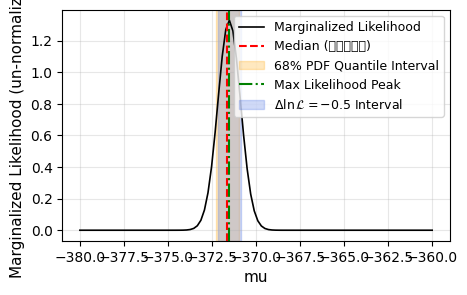

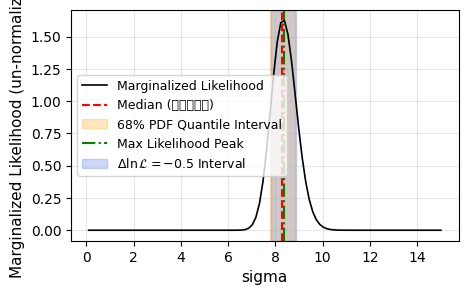

In [ ]:
lnL_map, mu_grid, sig_grid = get_L2d("data/cas3.csv", min_mu=-380, max_mu=-360, min_sig=0.1, max_sig=15, e_vr_on=True)
L1d_mu, L1d_sig, dmu, dsig = get_L1d(lnL_map, mu_grid, sig_grid)
mu_med, mu16, mu84 = get_quantile_interval(L1d_mu, mu_grid, dmu)
mu_peak, mu_l, mu_r = get_likelihood_interval(L1d_mu, mu_grid)
sig_med, sig16, sig84 = get_quantile_interval(L1d_sig, sig_grid, dsig)
sig_peak, sig_l, sig_r = get_likelihood_interval(L1d_sig, sig_grid)

print("平均视向速度")
print(f"分位数法：中位数={mu_med:.2f}, 16%={mu16:.2f}, 84%={mu84:.2f}")
print(f"似然阈值法：峰值={mu_peak:.2f}, 左边界={mu_l:.2f}, 右边界={mu_r:.2f}")
print("\n速度弥散")
print(f"分位数法：中位数={sig_med:.2f}, 16%={sig16:.2f}, 84%={sig84:.2f}")
print(f"似然阈值法：峰值={sig_peak:.2f}, 左边界={sig_l:.2f}, 右边界={sig_r:.2f}")

plot_marginal_likelihood(mu_grid, L1d_mu, mu_med, mu16, mu84, mu_peak, mu_l, mu_r, "mu")
plot_marginal_likelihood(sig_grid, L1d_sig, sig_med, sig16, sig84, sig_peak, sig_l, sig_r, "sigma")

平均视向速度
分位数法：中位数=-377.03, 16%=-379.32, 84%=-374.78
似然阈值法：峰值=-376.87, 左边界=-379.00, 右边界=-374.81

速度弥散
分位数法：中位数=5.34, 16%=2.93, 84%=8.21
似然阈值法：峰值=5.07, 左边界=2.89, 右边界=7.57


c:\Users\32166\miniconda3\envs\astronomy\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\32166\miniconda3\envs\astronomy\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\32166\miniconda3\envs\astronomy\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\32166\miniconda3\envs\astronomy\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\32166\miniconda3\envs\astronomy\lib\site-packages\IPython\core\pylabtools.py:170: UserWarni

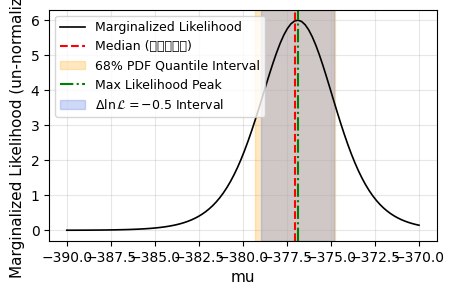

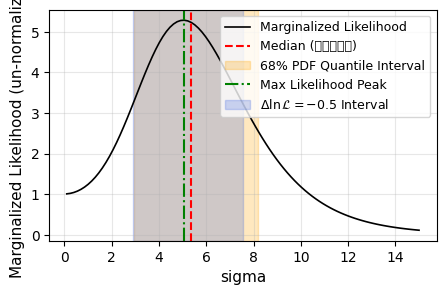

In [ ]:
lnL_map, mu_grid, sig_grid = get_L2d("data/cas3.csv",num=10, min_mu=-390, max_mu=-370, min_sig=0.1, max_sig=15, e_vr_on=True)
L1d_mu, L1d_sig, dmu, dsig = get_L1d(lnL_map, mu_grid, sig_grid)
mu_med, mu16, mu84 = get_quantile_interval(L1d_mu, mu_grid, dmu)
mu_peak, mu_l, mu_r = get_likelihood_interval(L1d_mu, mu_grid)
sig_med, sig16, sig84 = get_quantile_interval(L1d_sig, sig_grid, dsig)
sig_peak, sig_l, sig_r = get_likelihood_interval(L1d_sig, sig_grid)

print("平均视向速度")
print(f"分位数法：中位数={mu_med:.2f}, 16%={mu16:.2f}, 84%={mu84:.2f}")
print(f"似然阈值法：峰值={mu_peak:.2f}, 左边界={mu_l:.2f}, 右边界={mu_r:.2f}")
print("\n速度弥散")
print(f"分位数法：中位数={sig_med:.2f}, 16%={sig16:.2f}, 84%={sig84:.2f}")
print(f"似然阈值法：峰值={sig_peak:.2f}, 左边界={sig_l:.2f}, 右边界={sig_r:.2f}")

plot_marginal_likelihood(mu_grid, L1d_mu, mu_med, mu16, mu84, mu_peak, mu_l, mu_r, "mu")
plot_marginal_likelihood(sig_grid, L1d_sig, sig_med, sig16, sig84, sig_peak, sig_l, sig_r, "sigma")